# Exercise 2 — Enhancement of nature_dark_forest.jpg in terms of perceived light and color

Student: Konstantinos Kritsotakis

Registration Number: 7115152500007  

Course: Image Analysis and Processing (2025–2026) 

## Proposed method

The image `nature_dark_forest.jpg` is a dark RGB image with low visibility in several regions, especially on the right side of the forest and along parts of the railway track. The main goal is to improve the perceived illumination, reveal hidden details, and slightly improve the color appearance, while preserving the natural dark and foggy atmosphere of the scene.

A direct enhancement of the RGB channels independently is not ideal, because it may distort the color balance of the image. For this reason, the proposed method first converts the image from RGB to the LAB color space.

In the LAB color space, the image is represented as:

$$
LAB = (L, A, B)
$$

where:

- \(L\) represents lightness,
- \(A\) represents the green-red color component,
- \(B\) represents the blue-yellow color component.

This separation is useful because the brightness can be enhanced mainly through the \(L\) channel, while the chromatic information in \(A\) and \(B\) is mostly preserved. Therefore, the method improves perceived light without strongly distorting the original colors.

The proposed enhancement pipeline is:

$$
RGB \rightarrow LAB \rightarrow \text{gamma correction on } L \rightarrow \text{CLAHE on } L_{\gamma} \rightarrow \text{blending} \rightarrow RGB \rightarrow HSV \rightarrow \text{mild saturation enhancement}
$$

---

## Step 1 — Safe image loading and RGB conversion

The image was loaded using a safer method for Windows paths that may contain Unicode or Greek characters. Instead of using `cv2.imread()` directly, the file was first read as bytes and then decoded using OpenCV.

OpenCV loads color images in BGR order. Therefore, the image was converted from BGR to RGB before visualization, because Matplotlib expects RGB images.

This ensures that the displayed colors are correct.

---

## Step 2 — Conversion from RGB to LAB

The RGB image was converted to the LAB color space:

$$
RGB \rightarrow LAB
$$

This was done in order to separate lightness from color information. The \(L\) channel was then extracted and used as the main target for brightness and contrast enhancement.

This is important because changing the \(L\) channel affects mainly the perceived lightness of the image, whereas keeping the \(A\) and \(B\) channels mostly unchanged helps preserve the natural color structure of the scene.

---

## Step 3 — Gamma correction on the \(L\) channel

Gamma correction was applied to the \(L\) channel in order to increase perceived brightness, especially in dark and mid-tone regions.

The gamma correction formula is:

$$
L_{\gamma} = 255 \left(\frac{L}{255}\right)^{1/\gamma}
$$

where:

$$
\gamma = 1.6
$$

Since \(\gamma > 1\), the exponent \(1/\gamma\) is smaller than 1. Therefore, dark and mid-tone values are increased more strongly than already bright values.

For example:

$$
L = 50 \Rightarrow L_{\gamma} \approx 93
$$

whereas:

$$
L = 200 \Rightarrow L_{\gamma} \approx 219
$$

Thus, gamma correction brightens the image, but it affects darker regions more visibly than already bright areas. This is suitable for this image because many important details are hidden in dark regions.

---

## Step 4 — CLAHE on the gamma-corrected \(L\) channel

After gamma correction, CLAHE was applied to the corrected lightness channel \(L_{\gamma}\).

CLAHE stands for:

$$
\text{Contrast Limited Adaptive Histogram Equalization}
$$

Unlike standard histogram equalization, which is applied globally to the whole image, CLAHE works locally. It divides the image into small tiles and applies histogram equalization separately in each tile.

In this implementation:

$$
\text{tileGridSize} = (8,8)
$$

so the image is divided into:

$$
8 \times 8 = 64
$$

local regions.

CLAHE improves local contrast, which is useful for revealing details in areas such as the railway track, the forest texture, and the rocky regions.

The parameter:

$$
\text{clipLimit} = 2.0
$$

limits excessive contrast amplification. This prevents the method from over-enhancing noise or producing an unnatural result.

Mathematically, if a histogram bin \(h(i)\) is too large, it is clipped:

$$
h_{\text{clipped}}(i)=\min(h(i),T)
$$

where \(T\) is the clipping threshold. The excess counts are redistributed to the histogram before computing the cumulative distribution function. This keeps the total number of pixels unchanged while preventing excessive local enhancement.

Therefore, CLAHE increases local contrast in a controlled way.

---

## Step 5 — Conservative blending of gamma correction and CLAHE

CLAHE can sometimes make an image look overprocessed. To avoid this, the CLAHE result was blended with the gamma-corrected result.

The blending formula was:

$$
L_{\text{enhanced}} = 0.65L_{\text{CLAHE}} + 0.35L_{\gamma}
$$

This means that the final enhanced lightness channel contains:

- 65% of the CLAHE-enhanced result,
- 35% of the gamma-corrected result.

This conservative blending keeps the benefits of local contrast enhancement, while reducing the risk of an artificial appearance.

---

## Step 6 — Reconstruction of the RGB image

After enhancing the \(L\) channel, the image was reconstructed in LAB space:

$$
LAB_{\text{enhanced}} = (L_{\text{enhanced}}, A, B)
$$

Then it was converted back to RGB:

$$
LAB_{\text{enhanced}} \rightarrow RGB
$$

At this point, the image has improved brightness and local contrast, while the original chromatic structure is largely preserved.

---

## Step 7 — Mild saturation enhancement in HSV

After the brightness and contrast enhancement, a mild color enhancement was applied in the HSV color space.

The enhanced RGB image was converted to HSV:

$$
RGB \rightarrow HSV
$$

In HSV:

- \(H\) is hue,
- \(S\) is saturation,
- \(V\) is value/brightness.

Only the saturation channel was slightly increased:

$$
S_{\text{new}} = 1.15S_{\text{old}}
$$

with clipping to keep the values inside the valid range:

$$
S_{\text{final}} = \text{clip}(1.15S,0,255)
$$

This increases color vividness by 15%. The increase is intentionally mild, because the original scene is a dark, foggy forest. A stronger saturation increase could make the image unrealistic or artificial.

Finally, the image was converted back to RGB.

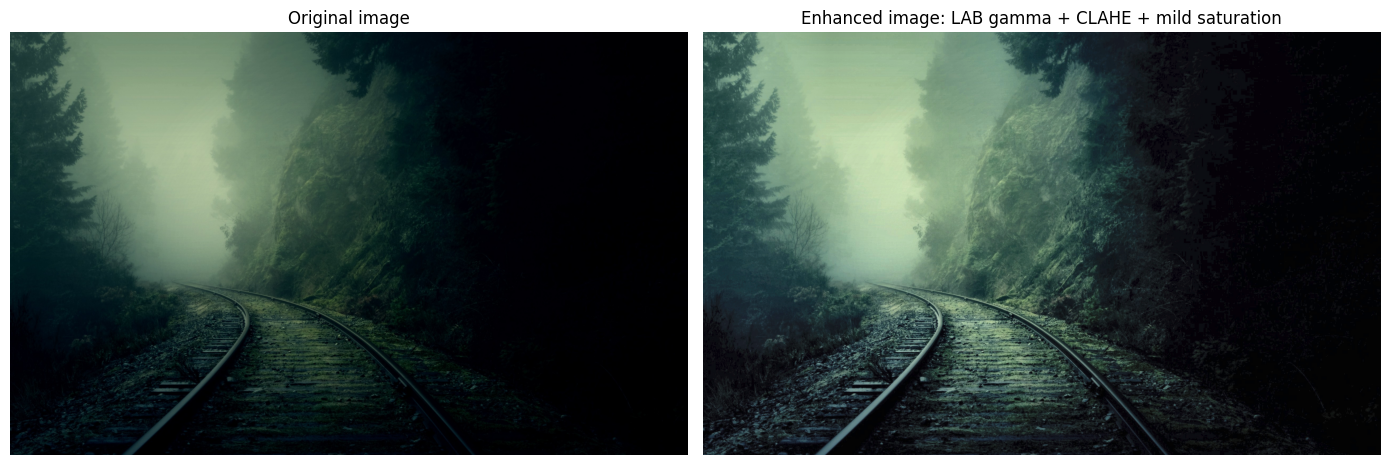

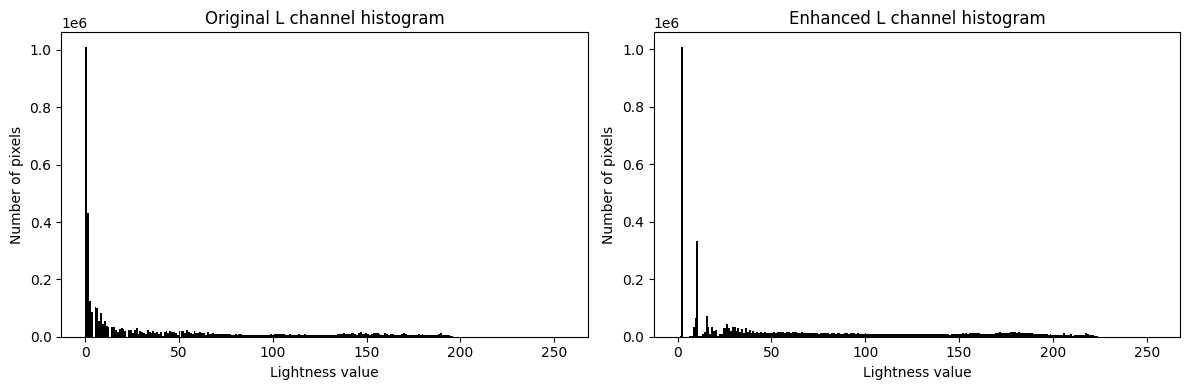

Original L channel:
Min: 0
Max: 198
Mean: 41.96
Standard deviation: 56.56

Enhanced L channel:
Min: 1
Max: 227
Mean: 65.81
Standard deviation: 67.96

Conclusion:
The LAB color space was used so that brightness was enhanced mainly through the L channel.
Gamma correction increased perceived lightness in dark and mid-tone regions.
CLAHE improved local contrast and revealed details in dark areas.
A mild saturation increase improved color appearance without strongly distorting natural colors.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# 1. Load image safely from a Windows path with Greek characters
# ---------------------------------------------------------
IMAGE_PATH = Path("nature_dark_forest.jpg")

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

# cv2.imread may fail with Unicode/Greek paths on Windows.
# This method is safer.
image_bytes = np.fromfile(str(IMAGE_PATH), dtype=np.uint8)
bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

if bgr is None:
    raise ValueError("The image could not be loaded. Check file integrity.")

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# 2. Convert RGB to LAB
# LAB separates lightness from color information.
# We enhance only the L channel to avoid distorting colors.
# ---------------------------------------------------------
lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)

L, A, B = cv2.split(lab)

# ---------------------------------------------------------
# 3. Gamma correction on the L channel
# For gamma > 1, dark and mid-tone regions become brighter.
# ---------------------------------------------------------
def gamma_correction(channel, gamma=1.6):
    channel_norm = channel.astype(np.float32) / 255.0
    corrected = np.power(channel_norm, 1.0 / gamma)
    corrected = np.clip(corrected * 255.0, 0, 255)
    return corrected.astype(np.uint8)

gamma = 1.6
L_gamma = gamma_correction(L, gamma=gamma)

# ---------------------------------------------------------
# 4. CLAHE on the corrected L channel
# CLAHE improves local contrast without excessive global over-enhancement.
# ---------------------------------------------------------
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

L_clahe = clahe.apply(L_gamma)

# Optional conservative blending:
# This avoids an overprocessed look by combining gamma correction and CLAHE.
alpha = 0.65
L_enhanced = cv2.addWeighted(L_clahe, alpha, L_gamma, 1 - alpha, 0)

# ---------------------------------------------------------
# 5. Merge enhanced L with original color channels A and B
# ---------------------------------------------------------
lab_enhanced = cv2.merge((L_enhanced, A, B))
rgb_light_enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

# ---------------------------------------------------------
# 6. Mild saturation enhancement in HSV
# This improves color appearance without making the forest unrealistic.
# ---------------------------------------------------------
hsv = cv2.cvtColor(rgb_light_enhanced, cv2.COLOR_RGB2HSV).astype(np.float32)

saturation_factor = 1.15
hsv[:, :, 1] = np.clip(hsv[:, :, 1] * saturation_factor, 0, 255)

hsv = hsv.astype(np.uint8)
rgb_final = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# ---------------------------------------------------------
# 7. Display original and enhanced images
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rgb_final)
plt.title("Enhanced image: LAB gamma + CLAHE + mild saturation")
plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Display L-channel histograms before and after enhancement
# ---------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=(0, 255), color="black")
plt.title("Original L channel histogram")
plt.xlabel("Lightness value")
plt.ylabel("Number of pixels")

plt.subplot(1, 2, 2)
plt.hist(L_enhanced.ravel(), bins=256, range=(0, 255), color="black")
plt.title("Enhanced L channel histogram")
plt.xlabel("Lightness value")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Numerical confirmation
# ---------------------------------------------------------
print("Original L channel:")
print("Min:", L.min())
print("Max:", L.max())
print("Mean:", round(float(L.mean()), 2))
print("Standard deviation:", round(float(L.std()), 2))

print("\nEnhanced L channel:")
print("Min:", L_enhanced.min())
print("Max:", L_enhanced.max())
print("Mean:", round(float(L_enhanced.mean()), 2))
print("Standard deviation:", round(float(L_enhanced.std()), 2))

print("\nConclusion:")
print("The LAB color space was used so that brightness was enhanced mainly through the L channel.")
print("Gamma correction increased perceived lightness in dark and mid-tone regions.")
print("CLAHE improved local contrast and revealed details in dark areas.")
print("A mild saturation increase improved color appearance without strongly distorting natural colors.")

---

## Interpretation of the visual result

The original image is very dark, especially in the right forest region and in several parts of the railway track. Many details are difficult to distinguish because most lightness values are concentrated in the low-intensity range.

After enhancement, the image is visibly brighter. The railway track, the ground texture, the vegetation, and the rocky area become more visible. The local contrast is also improved, so edges and textures are easier to perceive.

Importantly, the enhanced image still preserves the dark and foggy atmosphere of the original scene. The method does not simply overexpose the image. Instead, it improves perceived light and detail visibility in a controlled way.

The mild saturation enhancement also makes the green and blue-green tones slightly more visible, without making the forest look unnatural.

---

## Interpretation of the L-channel histograms

The histogram of the original \(L\) channel shows a very large concentration of pixels near low lightness values, especially close to zero. This confirms that the image is visually dark and that many pixels belong to very dark regions.

The enhanced \(L\) channel histogram is shifted toward higher lightness values and is more spread out. This indicates that the brightness and contrast of the image have increased.

The enhanced histogram still contains many low-lightness pixels. This is expected and acceptable, because the image naturally contains very dark regions. The aim was not to remove all shadows, but to improve visibility while preserving the mood of the scene.

---

## Numerical confirmation

The numerical results support the visual interpretation.

For the original \(L\) channel:

$$
\min = 0
$$

$$
\max = 198
$$

$$
\text{mean} = 41.96
$$

$$
\text{standard deviation} = 56.56
$$

The low mean value confirms that the original image is globally dark.

For the enhanced \(L\) channel:

$$
\min = 1
$$

$$
\max = 227
$$

$$
\text{mean} = 65.81
$$

$$
\text{standard deviation} = 67.96
$$

The mean lightness increased from:

$$
41.96 \rightarrow 65.81
$$

This confirms that the image became brighter.

The maximum lightness increased from:

$$
198 \rightarrow 227
$$

This shows that the available lightness range was extended.

The standard deviation increased from:

$$
56.56 \rightarrow 67.96
$$

This indicates increased contrast, because the lightness values became more spread out.

Therefore, both the visual results and the numerical measurements confirm that the method improved the perceived illumination and contrast of the image.

---

## Final conclusion

The proposed method enhances `nature_dark_forest.jpg` by combining LAB-based lightness enhancement, gamma correction, CLAHE, conservative blending, and mild HSV saturation enhancement.

The use of LAB is appropriate because it allows the brightness to be modified mainly through the \(L\) channel without strongly distorting the color channels. Gamma correction increases perceived brightness, especially in dark and mid-tone regions. CLAHE improves local contrast and reveals details in dark areas. Blending prevents an overprocessed appearance. Finally, a mild saturation increase improves the color appearance without making the image look unnatural.

Overall, the method successfully improves perceived light, enhances local detail visibility, increases contrast, and slightly improves color vividness while preserving the natural dark and foggy atmosphere of the original image.